In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sudeshnamandal03/imageszip/__huggingface_repos__.json
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_2104.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_1306.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_3946.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_2771.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_3912.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_0519.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_1466.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_0213.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_3167.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_1410.jpg
/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images/IMG_0420.jpg
/kaggle/in

In [2]:
import subprocess, sys

subprocess.run([sys.executable, '-m', 'pip', 'uninstall', '-y',
                'torch', 'torchvision', 'torchaudio'])

subprocess.run([sys.executable, '-m', 'pip', 'install',
                'torch==2.6.0',
                'torchvision==0.21.0',
                'torchaudio==2.6.0',
                '--index-url', 'https://download.pytorch.org/whl/cu124',
                '-q'])

print('✅ Done. Now restart session.')

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

In [3]:
!pip install timm --quiet

import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch.nn.functional as F

import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# ── Device: use GPU if available, else CPU ────────────────────────────
# GPU makes training 10x faster
# If this prints 'cpu', go to Kaggle right sidebar → Session Options → Accelerator → GPU T4 x2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️ WARNING: Running on CPU. Training will be slow.')
    print('Go to: Right Sidebar → Session Options → Accelerator → GPU T4 x2 → Save')

Device: cuda
GPU Name: Tesla P100-PCIE-16GB
GPU Memory: 17.1 GB


Total rows: 4000
Columns: ['IMAGE ID', 'ETHNICITY', 'GENDER', 'AGE GROUP', 'AGE', 'REGION STATE', 'SKIN TONE', 'FACE SHAPE', 'HAIR LENGTH', 'HAIR TYPE', 'HAIR COLOR', 'EYE COLOR', 'EYE SHAPE', 'NOSE TYPE', 'LIP TYPE', 'FACIAL HAIR', 'EXPRESSION', 'PROMPT']

Class distribution:
ETHNICITY   GENDER
Indian      Female    1000
            Male      1000
Not-Indian  Female    1000
            Male      1000
dtype: int64


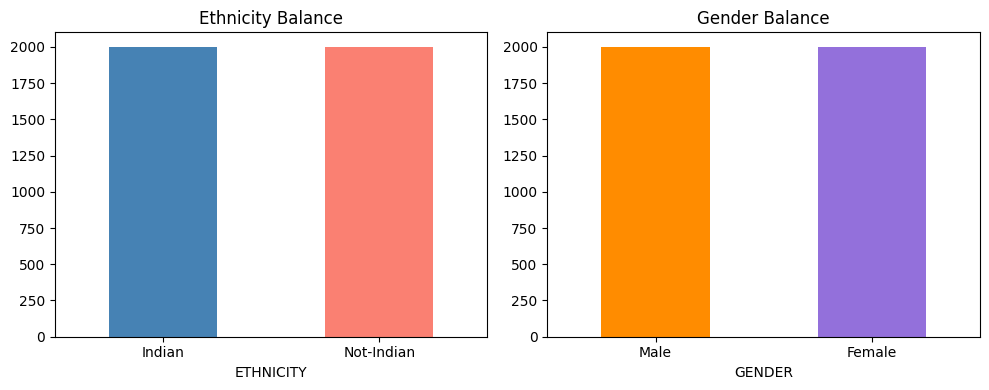

,IMAGE ID,ETHNICITY,GENDER,AGE GROUP,AGE,REGION STATE,SKIN TONE,FACE SHAPE,HAIR LENGTH,HAIR TYPE,...,EYE COLOR,EYE SHAPE,NOSE TYPE,LIP TYPE,FACIAL HAIR,EXPRESSION,PROMPT,eth_label,gen_label,filename
0,IMG_0001,Indian,Male,26-35,33,Uttarakhand,Dusky,Round,Shaved,Straight,...,Brown,Wide-set,Button,Medium,Full Beard,Joyful,A photorealistic portrait of a 33-year-old Ind...,1,1,IMG_0001.jpg
1,IMG_0002,Indian,Male,66-74,74,West Bengal,Dusky,Round,Shaved,Frizzy,...,Green,Narrow,Aquiline,Full,Goatee,Confident,A photorealistic portrait of a 74-year-old Ind...,1,1,IMG_0002.jpg
2,IMG_0003,Indian,Male,46-55,53,Uttar Pradesh,Wheatish,Heart,Shaved,Curly,...,Blue,Almond,Bulbous,Thin,Light Stubble,Joyful,A photorealistic portrait of a 53-year-old Ind...,1,1,IMG_0003.jpg
3,IMG_0004,Indian,Male,26-35,27,Tamil Nadu,Dark,Diamond,Short,Curly,...,Black,Wide-set,Button,Medium,Heavy Stubble,Pensive,A photorealistic portrait of a 27-year-old Ind...,1,1,IMG_0004.jpg
4,IMG_0005,Indian,Male,46-55,47,Bihar,Fair,Oblong,Bald,Wavy,...,Hazel,Almond,Flat,Thin,Clean-shaven,Smiling,A photorealistic portrait of a 47-year-old Ind...,1,1,IMG_0005.jpg


In [4]:
# ── Exact Kaggle paths from your dataset ─────────────────────────────
EXCEL_PATH = '/kaggle/input/datasets/sudeshnamandal03/finalperfectlybalanced/indian_faces_perfectly_balanced.xlsx'
IMG_DIR    = '/kaggle/input/datasets/sudeshnamandal03/imageszip/indian_faces_images'

# ── Load Excel ────────────────────────────────────────────────────────
df = pd.read_excel(EXCEL_PATH)
print(f'Total rows: {len(df)}')
print(f'Columns: {df.columns.tolist()}')

# ── Encode string labels to integers ─────────────────────────────────
# Model needs numbers, not strings
df['eth_label'] = (df['ETHNICITY'] == 'Indian').astype(int)   # Indian=1, Not-Indian=0
df['gen_label'] = (df['GENDER']    == 'Male').astype(int)     # Male=1,   Female=0
df['filename']  = df['IMAGE ID'].astype(str) + '.jpg'         # IMG_0001 → IMG_0001.jpg

print('\nClass distribution:')
print(df.groupby(['ETHNICITY', 'GENDER']).size())

# ── Visual check of balance ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['ETHNICITY'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'],
                                     title='Ethnicity Balance', rot=0)
df['GENDER'].value_counts().plot(kind='bar', ax=axes[1], color=['darkorange','mediumpurple'],
                                  title='Gender Balance', rot=0)
plt.tight_layout()
plt.show()

df.head()

Total images found: 4000


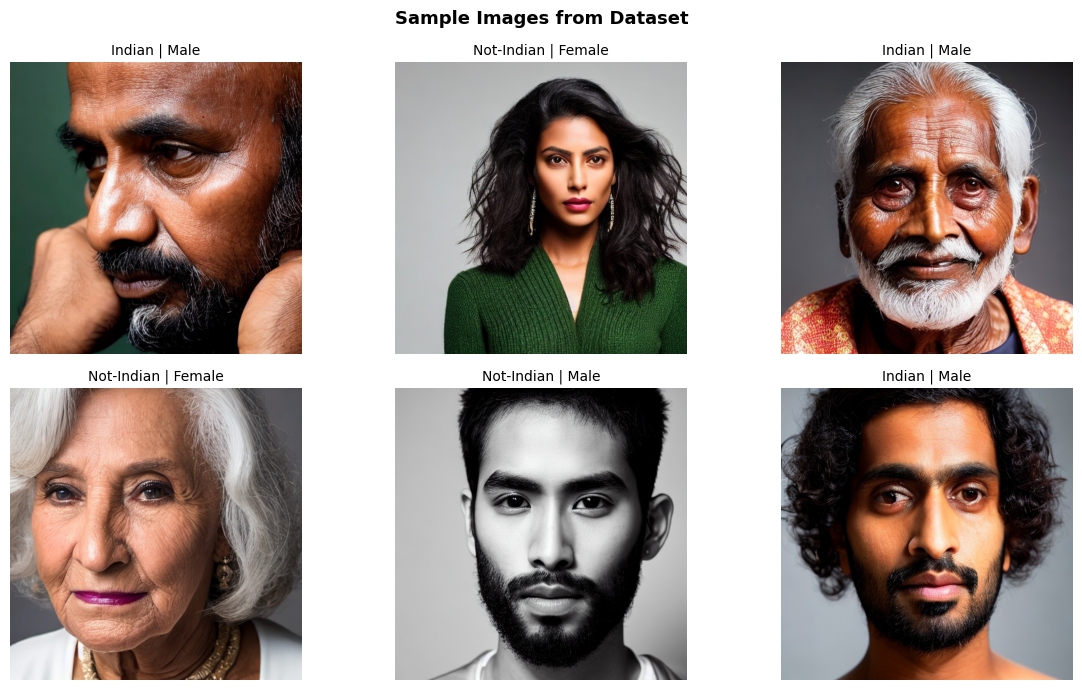

✅ Images verified and accessible.


In [5]:
# ── Verify images are accessible ─────────────────────────────────────
# No extraction needed — images already available in Kaggle input
img_files = os.listdir(IMG_DIR)
print(f'Total images found: {len(img_files)}')

# ── Show 6 random sample images ──────────────────────────────────────
sample_rows = df.sample(6, random_state=42)
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    img = mpimg.imread(os.path.join(IMG_DIR, row['filename']))
    ax.imshow(img)
    ax.set_title(f"{row['ETHNICITY']} | {row['GENDER']}", fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Images from Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ Images verified and accessible.')

In [6]:
# ── Combined key for stratified splitting ────────────────────────────
# Ensures equal distribution of all 4 combinations in every split
df['strat_key'] = df['eth_label'].astype(str) + '_' + df['gen_label'].astype(str)

# ── Split 70 / 15 / 15 ───────────────────────────────────────────────
train_df, temp_df = train_test_split(df,      test_size=0.30, stratify=df['strat_key'],      random_state=42)
val_df,   test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['strat_key'], random_state=42)

print(f'Train:      {len(train_df)} images')
print(f'Validation: {len(val_df)}   images')
print(f'Test:       {len(test_df)}  images')
print(f'Total:      {len(train_df)+len(val_df)+len(test_df)} images')

print('\nTrain split distribution:')
print(train_df.groupby(['ETHNICITY','GENDER']).size())

Train:      2800 images
Validation: 600   images
Test:       600  images
Total:      4000 images

Train split distribution:
ETHNICITY   GENDER
Indian      Female    700
            Male      700
Not-Indian  Female    700
            Male      700
dtype: int64


In [7]:
IMG_SIZE = 224   # EfficientNet-B0 input size

# ImageNet statistics — required because model was pretrained on ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Training transforms — adds variation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),        # mirror image randomly
    transforms.RandomRotation(degrees=10),          # slight tilt
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),         # lighting variation
    transforms.ToTensor(),                          # convert to tensor [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN,
                         std=IMAGENET_STD)           # normalize to ImageNet scale
])

# Validation/Test transforms — no random changes, just resize + normalize
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])


class FaceDataset(Dataset):
    """
    Custom Dataset that:
    1. Takes a dataframe row
    2. Loads the image from disk
    3. Applies transforms
    4. Returns (image_tensor, ethnicity_label, gender_label)
    """
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        # tells PyTorch how many samples exist
        return len(self.df)

    def __getitem__(self, idx):
        # loads one sample by index
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image    = Image.open(img_path).convert('RGB')  # always 3 channels

        if self.transform:
            image = self.transform(image)

        eth_label = torch.tensor(row['eth_label'], dtype=torch.long)
        gen_label = torch.tensor(row['gen_label'], dtype=torch.long)

        return image, eth_label, gen_label


# ── Create Dataset objects ────────────────────────────────────────────
train_dataset = FaceDataset(train_df, IMG_DIR, transform=train_transforms)
val_dataset   = FaceDataset(val_df,   IMG_DIR, transform=val_transforms)
test_dataset  = FaceDataset(test_df,  IMG_DIR, transform=val_transforms)

# ── Create DataLoaders ────────────────────────────────────────────────
# DataLoader feeds batches to the model during training
# batch_size=64: process 64 images at once (faster than 32)
# shuffle=True for train: randomize order each epoch (prevents pattern memorization)
# num_workers=2: load data in parallel (faster)
# pin_memory=True: faster GPU transfer
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')
print(f'Test batches:  {len(test_loader)}')

Batch size: 64
Train batches: 44
Val batches:   10
Test batches:  10


In [8]:
class IndianFaceClassifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()

        # Load EfficientNet-B0 pretrained on ImageNet
        # num_classes=0 removes the original 1000-class head
        # global_pool='avg' adds global average pooling → outputs a 1280-dim vector
        self.backbone = timm.create_model(
            'efficientnet_b0',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg'
        )
        feature_dim = self.backbone.num_features  # 1280 for B0

        # Dropout reduces overfitting by randomly turning off neurons during training
        self.dropout = nn.Dropout(p=0.3)

        # Head 1: Ethnicity classifier
        # 1280 → 256 → 2 (Indian or Not-Indian)
        self.eth_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

        # Head 2: Gender classifier
        # 1280 → 256 → 2 (Male or Female)
        self.gen_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        # x → backbone → features → both heads
        features   = self.backbone(x)
        features   = self.dropout(features)
        eth_logits = self.eth_head(features)
        gen_logits = self.gen_head(features)
        return eth_logits, gen_logits

    def freeze_backbone(self):
        # Stop backbone from updating — only heads train
        for param in self.backbone.parameters():
            param.requires_grad = False
        print('✅ Backbone FROZEN — training heads only (fast)')

    def unfreeze_backbone(self):
        # Allow entire model to update — full fine-tuning
        for param in self.backbone.parameters():
            param.requires_grad = True
        print('✅ Backbone UNFROZEN — fine-tuning entire model')


# ── Create model and move to GPU/CPU ──────────────────────────────────
model = IndianFaceClassifier(pretrained=True).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')
print(f'Feature dimension:    {model.backbone.num_features}')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Total parameters:     4,664,448
Trainable parameters: 4,664,448
Feature dimension:    1280


In [9]:
# ── Training phases ───────────────────────────────────────────────────
# Phase 1: Only heads train (backbone frozen) — 3 epochs
# Phase 2: Entire model trains (backbone unfrozen) — 7 epochs
EPOCHS_PHASE1 = 3
EPOCHS_PHASE2 = 7
TOTAL_EPOCHS  = EPOCHS_PHASE1 + EPOCHS_PHASE2  # = 10 total

LR_PHASE1 = 1e-3   # Higher LR for head-only training
LR_PHASE2 = 1e-4   # Lower LR for fine-tuning (prevent destroying pretrained weights)

# CrossEntropyLoss: measures how wrong the model's prediction is
# Lower loss = better predictions
criterion = nn.CrossEntropyLoss()

def get_optimizer_and_scheduler(model, lr, num_epochs):
    """
    AdamW optimizer: updates only trainable parameters
    weight_decay=1e-4: L2 regularization to reduce overfitting
    CosineAnnealingLR: smoothly reduces LR from lr to near 0 over num_epochs
    """
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )
    return optimizer, scheduler

print(f'Phase 1: {EPOCHS_PHASE1} epochs at LR={LR_PHASE1}')
print(f'Phase 2: {EPOCHS_PHASE2} epochs at LR={LR_PHASE2}')
print(f'Total:   {TOTAL_EPOCHS} epochs')

Phase 1: 3 epochs at LR=0.001
Phase 2: 7 epochs at LR=0.0001
Total:   10 epochs


In [10]:
def train_one_epoch(model, loader, optimizer):
    """
    Runs one full pass through all training batches.
    For each batch:
      1. Forward pass: image → model → predictions
      2. Loss: compare predictions to true labels
      3. Backward pass: compute gradients
      4. Update weights using optimizer
    """
    model.train()
    total_loss, eth_correct, gen_correct, total = 0.0, 0, 0, 0

    for images, eth_labels, gen_labels in loader:
        # Move data to GPU/CPU
        images     = images.to(device)
        eth_labels = eth_labels.to(device)
        gen_labels = gen_labels.to(device)

        optimizer.zero_grad()                            # clear old gradients
        eth_logits, gen_logits = model(images)           # forward pass

        # Compute loss for each task, then sum
        eth_loss = criterion(eth_logits, eth_labels)
        gen_loss = criterion(gen_logits, gen_labels)
        loss     = eth_loss + gen_loss

        loss.backward()                                  # backpropagation
        optimizer.step()                                 # update model weights

        # Track accuracy
        total_loss  += loss.item() * images.size(0)
        eth_correct += (eth_logits.argmax(1) == eth_labels).sum().item()
        gen_correct += (gen_logits.argmax(1) == gen_labels).sum().item()
        total       += images.size(0)

    return total_loss/total, eth_correct/total, gen_correct/total


def validate(model, loader):
    """
    Runs one full pass through validation/test data.
    No weight updates — just measures performance.
    torch.no_grad() skips gradient tracking → faster, less memory.
    """
    model.eval()
    total_loss, eth_correct, gen_correct, total = 0.0, 0, 0, 0

    with torch.no_grad():
        for images, eth_labels, gen_labels in loader:
            images     = images.to(device)
            eth_labels = eth_labels.to(device)
            gen_labels = gen_labels.to(device)

            eth_logits, gen_logits = model(images)

            eth_loss = criterion(eth_logits, eth_labels)
            gen_loss = criterion(gen_logits, gen_labels)
            loss     = eth_loss + gen_loss

            total_loss  += loss.item() * images.size(0)
            eth_correct += (eth_logits.argmax(1) == eth_labels).sum().item()
            gen_correct += (gen_logits.argmax(1) == gen_labels).sum().item()
            total       += images.size(0)

    return total_loss/total, eth_correct/total, gen_correct/total

print('✅ train_one_epoch() and validate() ready.')

✅ train_one_epoch() and validate() ready.


In [11]:
# ── Storage for plotting later ────────────────────────────────────────
history = {
    'train_loss':    [], 'val_loss':    [],
    'train_eth_acc': [], 'val_eth_acc': [],
    'train_gen_acc': [], 'val_gen_acc': []
}

best_val_eth_acc = 0.0
best_model_path  = '/kaggle/working/best_model.pth'

# ── Freeze backbone, setup optimizer ─────────────────────────────────
model.freeze_backbone()
optimizer, scheduler = get_optimizer_and_scheduler(model, LR_PHASE1, EPOCHS_PHASE1)

print(f'\n{"="*60}')
print(f'  PHASE 1 — Head Warmup ({EPOCHS_PHASE1} epochs)')
print(f'  Only ethnicity + gender heads are training')
print(f'{"="*60}')

phase1_start = time.time()

for epoch in range(1, EPOCHS_PHASE1 + 1):
    epoch_start = time.time()

    tr_loss, tr_eth, tr_gen = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_eth, vl_gen = validate(model, val_loader)
    scheduler.step()

    epoch_time = time.time() - epoch_start

    # Save history
    history['train_loss'].append(tr_loss);    history['val_loss'].append(vl_loss)
    history['train_eth_acc'].append(tr_eth);  history['val_eth_acc'].append(vl_eth)
    history['train_gen_acc'].append(tr_gen);  history['val_gen_acc'].append(vl_gen)

    # Save best model checkpoint
    if vl_eth > best_val_eth_acc:
        best_val_eth_acc = vl_eth
        torch.save(model.state_dict(), best_model_path)
        saved = '💾 saved'
    else:
        saved = ''

    print(f'Epoch {epoch:02d}/{EPOCHS_PHASE1} | '
          f'Time: {epoch_time/60:.1f}min | '
          f'Loss: {tr_loss:.3f}/{vl_loss:.3f} | '
          f'Eth: {tr_eth:.3f}/{vl_eth:.3f} | '
          f'Gen: {tr_gen:.3f}/{vl_gen:.3f} | '
          f'LR: {scheduler.get_last_lr()[0]:.1e} {saved}')

phase1_total = time.time() - phase1_start
print(f'\nPhase 1 complete in {phase1_total/60:.1f} minutes')

✅ Backbone FROZEN — training heads only (fast)

  PHASE 1 — Head Warmup (3 epochs)
  Only ethnicity + gender heads are training
Epoch 01/3 | Time: 0.4min | Loss: 0.652/0.442 | Eth: 0.831/0.850 | Gen: 0.889/0.933 | LR: 7.5e-04 💾 saved
Epoch 02/3 | Time: 0.3min | Loss: 0.421/0.417 | Eth: 0.884/0.892 | Gen: 0.940/0.928 | LR: 2.5e-04 💾 saved
Epoch 03/3 | Time: 0.3min | Loss: 0.387/0.343 | Eth: 0.903/0.893 | Gen: 0.941/0.955 | LR: 1.0e-06 💾 saved

Phase 1 complete in 0.9 minutes


In [12]:
# ── Unfreeze backbone, new optimizer with lower LR ────────────────────
model.unfreeze_backbone()
optimizer, scheduler = get_optimizer_and_scheduler(model, LR_PHASE2, EPOCHS_PHASE2)

print(f'\n{"="*60}')
print(f'  PHASE 2 — Full Fine-Tuning ({EPOCHS_PHASE2} epochs)')
print(f'  Entire model is training with LR={LR_PHASE2}')
print(f'{"="*60}')

phase2_start = time.time()

for epoch in range(1, EPOCHS_PHASE2 + 1):
    epoch_start = time.time()

    tr_loss, tr_eth, tr_gen = train_one_epoch(model, train_loader, optimizer)
    vl_loss, vl_eth, vl_gen = validate(model, val_loader)
    scheduler.step()

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(tr_loss);    history['val_loss'].append(vl_loss)
    history['train_eth_acc'].append(tr_eth);  history['val_eth_acc'].append(vl_eth)
    history['train_gen_acc'].append(tr_gen);  history['val_gen_acc'].append(vl_gen)

    if vl_eth > best_val_eth_acc:
        best_val_eth_acc = vl_eth
        torch.save(model.state_dict(), best_model_path)
        saved = '💾 saved'
    else:
        saved = ''

    print(f'Epoch {epoch:02d}/{EPOCHS_PHASE2} | '
          f'Time: {epoch_time/60:.1f}min | '
          f'Loss: {tr_loss:.3f}/{vl_loss:.3f} | '
          f'Eth: {tr_eth:.3f}/{vl_eth:.3f} | '
          f'Gen: {tr_gen:.3f}/{vl_gen:.3f} | '
          f'LR: {scheduler.get_last_lr()[0]:.1e} {saved}')

phase2_total = time.time() - phase2_start
print(f'\nPhase 2 complete in {phase2_total/60:.1f} minutes')
print(f'Total training time: {(phase2_total + phase1_total)/60:.1f} minutes')
print(f'\n🏆 Best Validation Ethnicity Accuracy: {best_val_eth_acc*100:.2f}%')

✅ Backbone UNFROZEN — fine-tuning entire model

  PHASE 2 — Full Fine-Tuning (7 epochs)
  Entire model is training with LR=0.0001
Epoch 01/7 | Time: 0.3min | Loss: 0.291/0.199 | Eth: 0.922/0.943 | Gen: 0.954/0.975 | LR: 9.5e-05 💾 saved
Epoch 02/7 | Time: 0.3min | Loss: 0.133/0.169 | Eth: 0.969/0.960 | Gen: 0.980/0.980 | LR: 8.1e-05 💾 saved
Epoch 03/7 | Time: 0.3min | Loss: 0.104/0.135 | Eth: 0.973/0.965 | Gen: 0.989/0.982 | LR: 6.2e-05 💾 saved
Epoch 04/7 | Time: 0.3min | Loss: 0.061/0.123 | Eth: 0.985/0.973 | Gen: 0.992/0.982 | LR: 3.9e-05 💾 saved
Epoch 05/7 | Time: 0.3min | Loss: 0.035/0.114 | Eth: 0.994/0.973 | Gen: 0.998/0.982 | LR: 2.0e-05 
Epoch 06/7 | Time: 0.3min | Loss: 0.035/0.109 | Eth: 0.993/0.975 | Gen: 0.997/0.982 | LR: 5.9e-06 💾 saved
Epoch 07/7 | Time: 0.3min | Loss: 0.035/0.110 | Eth: 0.994/0.975 | Gen: 0.998/0.982 | LR: 1.0e-06 

Phase 2 complete in 2.0 minutes
Total training time: 2.9 minutes

🏆 Best Validation Ethnicity Accuracy: 97.50%


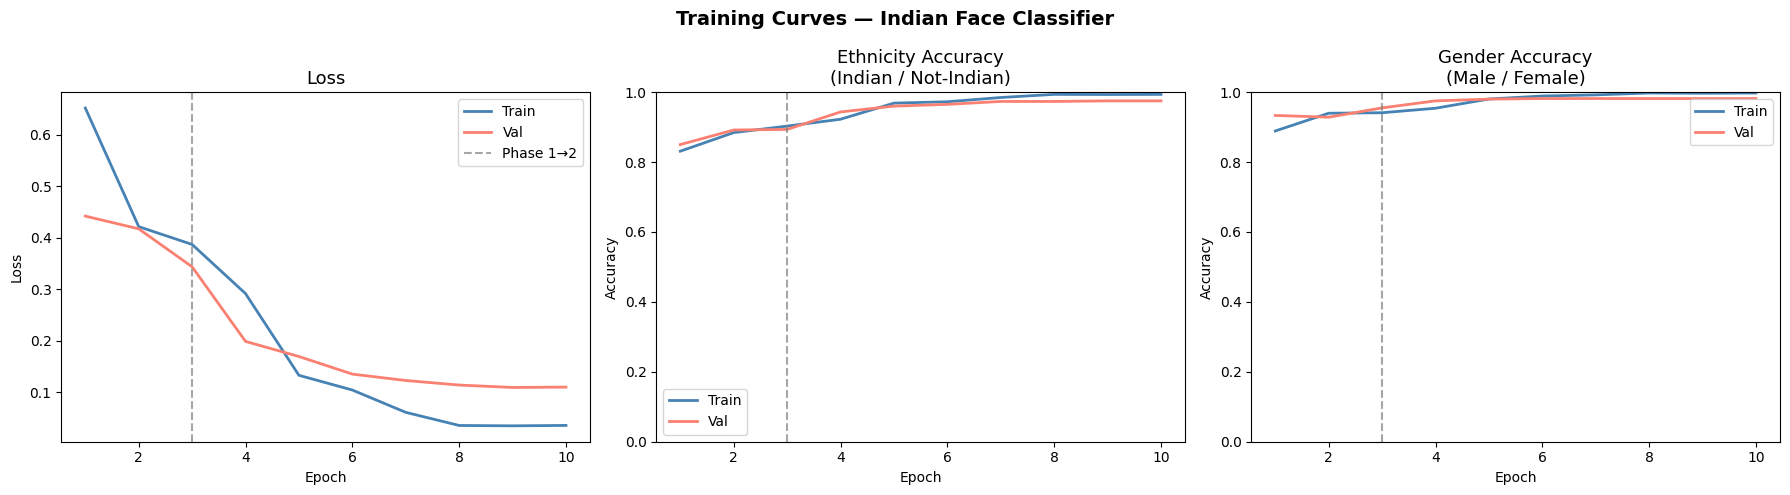

Saved: training_curves.png


In [13]:
epochs_range = range(1, TOTAL_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], label='Train', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='salmon',    linewidth=2)
axes[0].axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', alpha=0.7, label='Phase 1→2')
axes[0].set_title('Loss', fontsize=13); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

# Ethnicity accuracy plot
axes[1].plot(epochs_range, history['train_eth_acc'], label='Train', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, history['val_eth_acc'],   label='Val',   color='salmon',    linewidth=2)
axes[1].axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title('Ethnicity Accuracy\n(Indian / Not-Indian)', fontsize=13)
axes[1].legend(); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])

# Gender accuracy plot
axes[2].plot(epochs_range, history['train_gen_acc'], label='Train', color='steelblue', linewidth=2)
axes[2].plot(epochs_range, history['val_gen_acc'],   label='Val',   color='salmon',    linewidth=2)
axes[2].axvline(x=EPOCHS_PHASE1, color='gray', linestyle='--', alpha=0.7)
axes[2].set_title('Gender Accuracy\n(Male / Female)', fontsize=13)
axes[2].legend(); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy')
axes[2].set_ylim([0, 1])

plt.suptitle('Training Curves — Indian Face Classifier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

✅ Best model loaded.
ETHNICITY — Test Set Results
              precision    recall  f1-score   support

  Not-Indian       0.99      0.99      0.99       300
      Indian       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

GENDER — Test Set Results
              precision    recall  f1-score   support

      Female       0.98      0.99      0.99       300
        Male       0.99      0.98      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



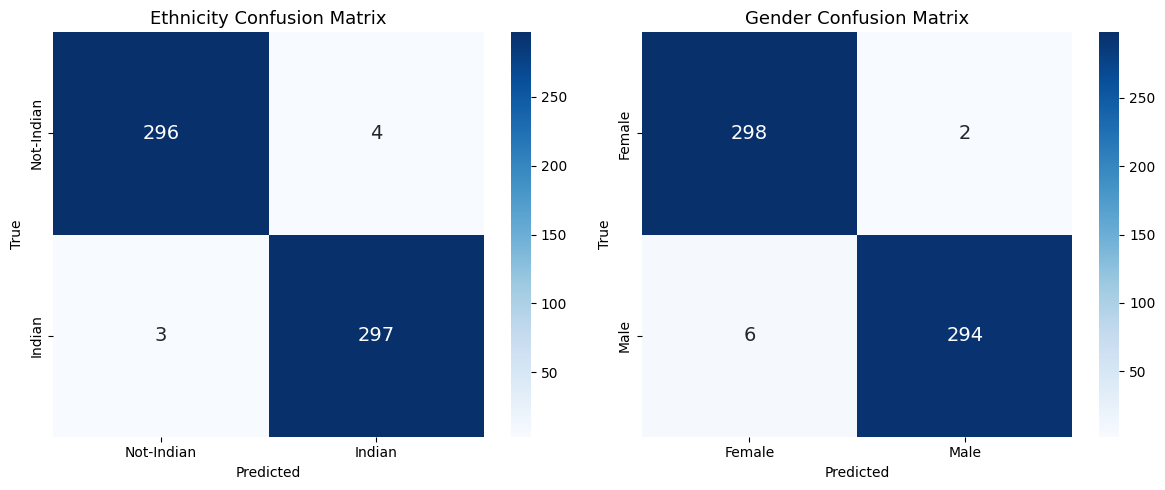

Saved: confusion_matrices.png


In [14]:
# ── Load the best checkpoint ──────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print('✅ Best model loaded.')

# ── Collect all predictions ───────────────────────────────────────────
all_eth_preds, all_eth_true = [], []
all_gen_preds, all_gen_true = [], []

with torch.no_grad():
    for images, eth_labels, gen_labels in test_loader:
        images = images.to(device)
        eth_logits, gen_logits = model(images)
        all_eth_preds.extend(eth_logits.argmax(1).cpu().numpy())
        all_eth_true.extend(eth_labels.numpy())
        all_gen_preds.extend(gen_logits.argmax(1).cpu().numpy())
        all_gen_true.extend(gen_labels.numpy())

# ── Print classification reports ─────────────────────────────────────
print('='*55)
print('ETHNICITY — Test Set Results')
print('='*55)
print(classification_report(all_eth_true, all_eth_preds,
                            target_names=['Not-Indian', 'Indian']))

print('='*55)
print('GENDER — Test Set Results')
print('='*55)
print(classification_report(all_gen_true, all_gen_preds,
                            target_names=['Female', 'Male']))

# ── Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, trues, labels, title in [
    (axes[0], all_eth_preds, all_eth_true, ['Not-Indian','Indian'], 'Ethnicity Confusion Matrix'),
    (axes[1], all_gen_preds, all_gen_true, ['Female','Male'],       'Gender Confusion Matrix')
]:
    cm = confusion_matrix(trues, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax, annot_kws={'size':14})
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

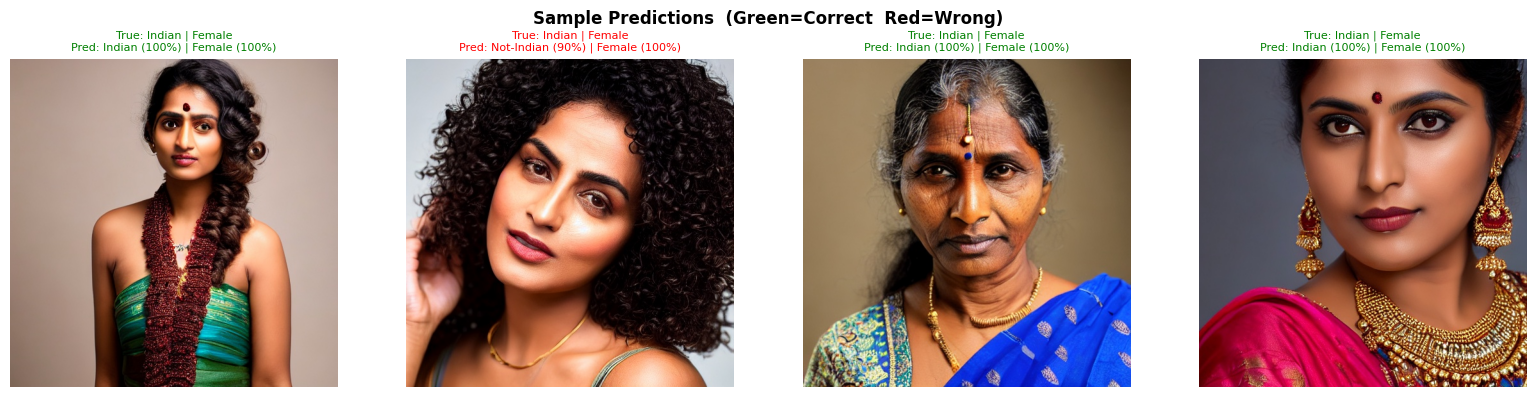

In [15]:
def predict(img_path, model):
    """
    Predict ethnicity and gender for any image.
    Returns: ethnicity, confidence%, gender, confidence%
    """
    model.eval()
    image  = Image.open(img_path).convert('RGB')
    tensor = val_transforms(image).unsqueeze(0).to(device)  # add batch dimension

    with torch.no_grad():
        eth_logits, gen_logits = model(tensor)

    # softmax converts raw scores → probabilities (0 to 1)
    eth_probs = F.softmax(eth_logits, dim=1).squeeze().cpu().numpy()
    gen_probs = F.softmax(gen_logits, dim=1).squeeze().cpu().numpy()

    eth_pred = 'Indian'     if eth_probs.argmax() == 1 else 'Not-Indian'
    gen_pred = 'Male'       if gen_probs.argmax() == 1 else 'Female'
    eth_conf = eth_probs.max() * 100
    gen_conf = gen_probs.max() * 100

    return eth_pred, eth_conf, gen_pred, gen_conf


# ── Test on 4 random images from test set ────────────────────────────
sample_rows = test_df.sample(4, random_state=99)
fig, axes   = plt.subplots(1, 4, figsize=(16, 4))

for ax, (_, row) in zip(axes, sample_rows.iterrows()):
    img_path = os.path.join(IMG_DIR, row['filename'])
    eth_pred, eth_conf, gen_pred, gen_conf = predict(img_path, model)

    correct = (eth_pred == row['ETHNICITY'] and gen_pred == row['GENDER'])
    color   = 'green' if correct else 'red'

    ax.imshow(Image.open(img_path))
    ax.set_title(
        f"True: {row['ETHNICITY']} | {row['GENDER']}\n"
        f"Pred: {eth_pred} ({eth_conf:.0f}%) | {gen_pred} ({gen_conf:.0f}%)",
        fontsize=8, color=color
    )
    ax.axis('off')

plt.suptitle('Sample Predictions  (Green=Correct  Red=Wrong)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Full checkpoint — includes metadata ───────────────────────────────
torch.save({
    'model_state_dict':  model.state_dict(),
    'model_arch':        'efficientnet_b0',
    'img_size':          IMG_SIZE,
    'eth_label_map':     {0: 'Not-Indian', 1: 'Indian'},
    'gen_label_map':     {0: 'Female',     1: 'Male'},
    'best_val_eth_acc':  best_val_eth_acc,
    'total_epochs':      TOTAL_EPOCHS,
    'history':           history
}, '/kaggle/working/full_checkpoint.pth')

# ── Weights only — smallest file, for inference only ──────────────────
torch.save(model.state_dict(), '/kaggle/working/model_weights_only.pth')

print('✅ Files saved to /kaggle/working/')
print('   best_model.pth          — best val checkpoint (saved during training)')
print('   full_checkpoint.pth     — full metadata checkpoint')
print('   model_weights_only.pth  — inference only')
print('   training_curves.png     — loss and accuracy plots')
print('   confusion_matrices.png  — confusion matrix plots')
print('   sample_predictions.png  — sample inference results')
print(f'\n🏆 Best Validation Ethnicity Accuracy: {best_val_eth_acc*100:.2f}%')

✅ Files saved to /kaggle/working/
   best_model.pth          — best val checkpoint (saved during training)
   full_checkpoint.pth     — full metadata checkpoint
   model_weights_only.pth  — inference only
   training_curves.png     — loss and accuracy plots
   confusion_matrices.png  — confusion matrix plots
   sample_predictions.png  — sample inference results

🏆 Best Validation Ethnicity Accuracy: 97.50%


✅ Best model loaded for evaluation.

        FINAL TEST SET ACCURACY SUMMARY
  Ethnicity Accuracy  : 98.83%
  Gender Accuracy     : 98.67%
  Both Correct        : 97.50%
  Avg Confidence (Eth): 97.94%
  Avg Confidence (Gen): 98.75%
  Total Test Images   : 600

ETHNICITY — Detailed Report
              precision    recall  f1-score   support

  Not-Indian       0.99      0.99      0.99       300
      Indian       0.99      0.99      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600

GENDER — Detailed Report
              precision    recall  f1-score   support

      Female       0.98      0.99      0.99       300
        Male       0.99      0.98      0.99       300

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



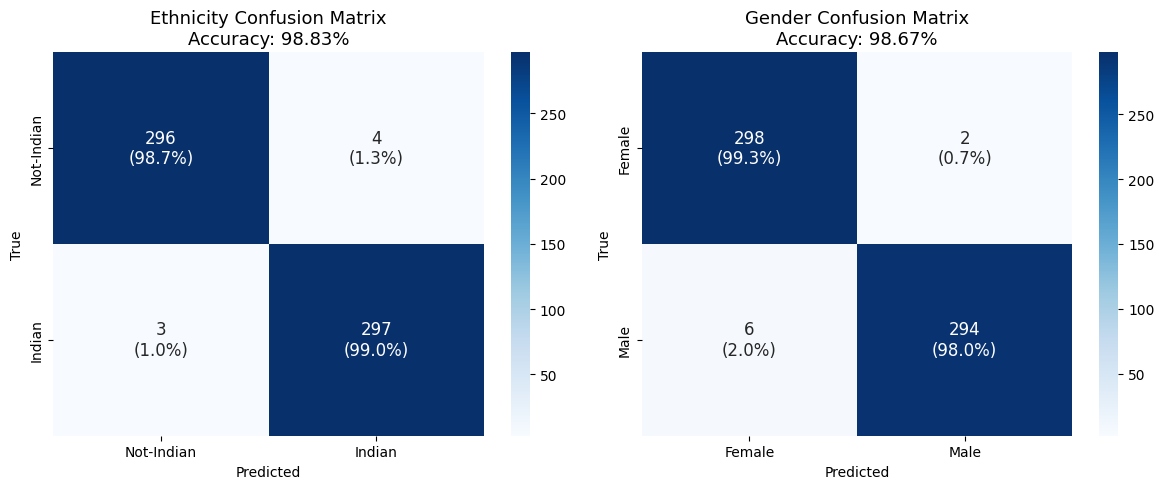

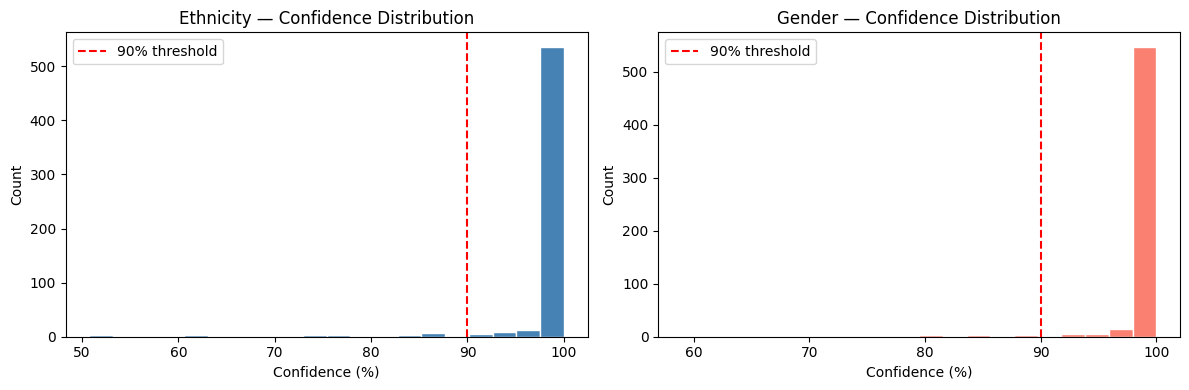


✅ Saved: test_accuracy_summary.png
✅ Saved: confidence_distribution.png


In [17]:
# ── Block 15 — Detailed Test Set Accuracy ────────────────────────────

import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ── Load best model ───────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print('✅ Best model loaded for evaluation.')

# ── Collect predictions ───────────────────────────────────────────────
all_eth_preds, all_eth_true = [], []
all_gen_preds, all_gen_true = [], []
all_eth_confs, all_gen_confs = [], []

with torch.no_grad():
    for images, eth_labels, gen_labels in test_loader:
        images = images.to(device)
        eth_logits, gen_logits = model(images)

        eth_probs = F.softmax(eth_logits, dim=1)
        gen_probs = F.softmax(gen_logits, dim=1)

        all_eth_preds.extend(eth_logits.argmax(1).cpu().numpy())
        all_eth_true.extend(eth_labels.numpy())
        all_gen_preds.extend(gen_logits.argmax(1).cpu().numpy())
        all_gen_true.extend(gen_labels.numpy())

        all_eth_confs.extend(eth_probs.max(1).values.cpu().numpy())
        all_gen_confs.extend(gen_probs.max(1).values.cpu().numpy())

# ── Accuracy Scores ───────────────────────────────────────────────────
eth_acc = accuracy_score(all_eth_true, all_eth_preds)
gen_acc = accuracy_score(all_gen_true, all_gen_preds)
both_correct = sum(e == et and g == gt for e, et, g, gt in 
                   zip(all_eth_preds, all_eth_true, all_gen_preds, all_gen_true))
combined_acc = both_correct / len(all_eth_true)

print('\n' + '='*55)
print('        FINAL TEST SET ACCURACY SUMMARY')
print('='*55)
print(f'  Ethnicity Accuracy  : {eth_acc*100:.2f}%')
print(f'  Gender Accuracy     : {gen_acc*100:.2f}%')
print(f'  Both Correct        : {combined_acc*100:.2f}%')
print(f'  Avg Confidence (Eth): {np.mean(all_eth_confs)*100:.2f}%')
print(f'  Avg Confidence (Gen): {np.mean(all_gen_confs)*100:.2f}%')
print(f'  Total Test Images   : {len(all_eth_true)}')
print('='*55)

# ── Per-class breakdown ───────────────────────────────────────────────
print('\nETHNICITY — Detailed Report')
print(classification_report(all_eth_true, all_eth_preds,
                            target_names=['Not-Indian', 'Indian']))

print('GENDER — Detailed Report')
print(classification_report(all_gen_true, all_gen_preds,
                            target_names=['Female', 'Male']))

# ── Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, trues, labels, title in [
    (axes[0], all_eth_preds, all_eth_true, ['Not-Indian','Indian'], 'Ethnicity'),
    (axes[1], all_gen_preds, all_gen_true, ['Female','Male'],       'Gender')
]:
    cm = confusion_matrix(trues, preds)
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    sns.heatmap(cm, annot=np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(row, prow)]
                for row, prow in zip(cm, cm_pct)]),
                fmt='', cmap='Blues', xticklabels=labels,
                yticklabels=labels, ax=ax, annot_kws={'size': 12})
    ax.set_title(f'{title} Confusion Matrix\nAccuracy: {accuracy_score(trues, preds)*100:.2f}%',
                 fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/kaggle/working/test_accuracy_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confidence Distribution ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(np.array(all_eth_confs)*100, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Ethnicity — Confidence Distribution')
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].axvline(x=90, color='red', linestyle='--', label='90% threshold')
axes[0].legend()

axes[1].hist(np.array(all_gen_confs)*100, bins=20, color='salmon', edgecolor='white')
axes[1].set_title('Gender — Confidence Distribution')
axes[1].set_xlabel('Confidence (%)')
axes[1].set_ylabel('Count')
axes[1].axvline(x=90, color='red', linestyle='--', label='90% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Saved: test_accuracy_summary.png')
print('✅ Saved: confidence_distribution.png')